## Color Image Segmentation using Thresholding-Based Segmentation technique in OpenCV

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

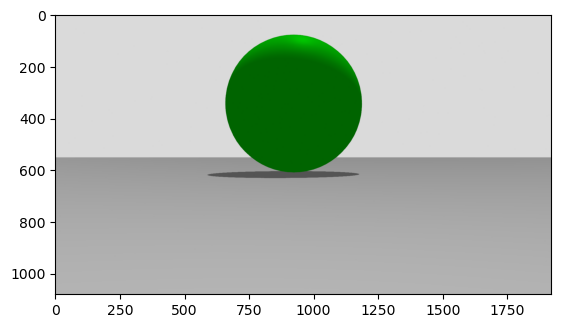

In [4]:
img=cv2.imread("/home/burhan/Downloads/camera_view.png")
plt.imshow(img)

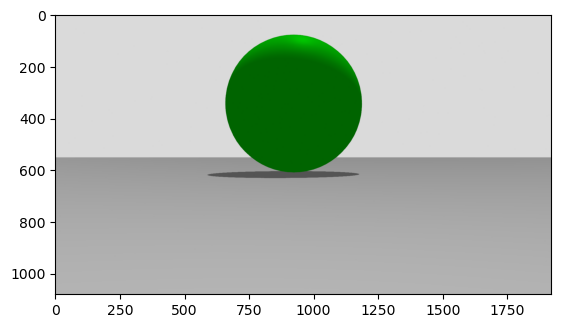

In [5]:
img_rgb=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [6]:
from mpl_toolkits.mplot3d import Axes3D

In [7]:
img_rgb.shape

(1080, 1920, 3)

In [8]:
#Splitting image into individual color channels
r, g, b= cv2.split(img_rgb)

In [9]:
print(r.shape)
print(g.shape)
print(b.shape)

(1080, 1920)
(1080, 1920)
(1080, 1920)


In [10]:
#Convert 2D array into 1D array
print(r.flatten().shape)
print(g.flatten().shape)
print(b.flatten().shape)

(2073600,)
(2073600,)
(2073600,)


In [11]:
#Dividing equal pixels to each color channel i.e 3
pixels=img_rgb.reshape(-1,3)
pixels.shape

(2073600, 3)

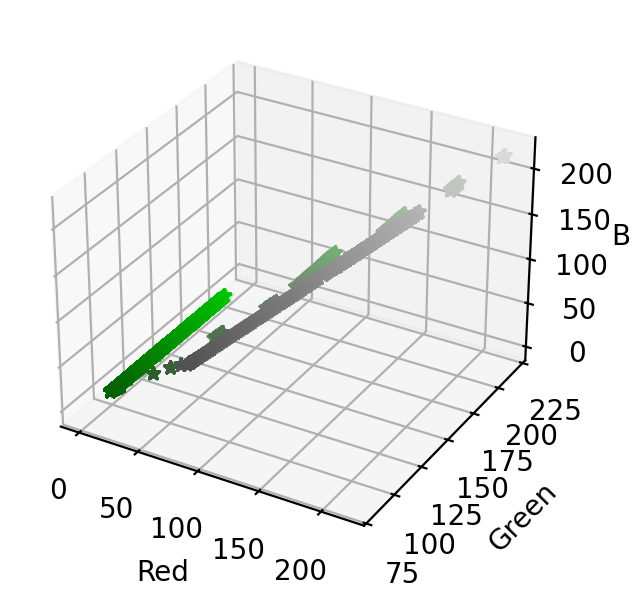

In [12]:
# Normalise to [0,1] for facecolors
pixel_colors=pixels/255.0 # Convert to float and scale

#create a 3D scatter plot
fig=plt.figure(figsize=(3,3), dpi=200)
ax=plt.axes(projection='3d')
ax.scatter(r,g,b, color=pixel_colors, marker='*')

#Label axes
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')

plt.tight_layout()
plt.show()

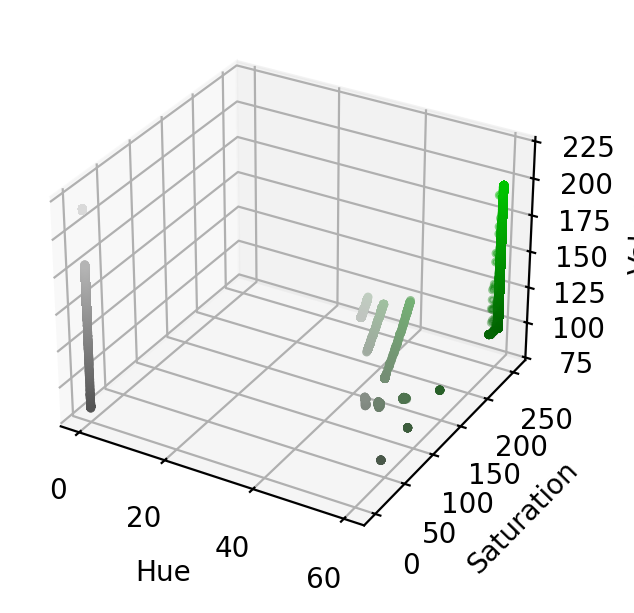

In [13]:
img_hsv=cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
h,s,v= cv2.split(img_hsv)

#Create a 3D scatter plot
fig=plt.figure(figsize=(3,3), dpi=200)
ax=plt.axes(projection='3d')
ax.scatter(h,s,v, color=pixel_colors, marker='.')

#Label axes
ax.set_xlabel('Hue')
ax.set_ylabel('Saturation')
ax.set_zlabel('Value')

plt.tight_layout()
plt.show()

In [14]:
#Create mask for orange color
lower_green_thresh=(40,150,50)
higher_green_thresh=(70,255,255)

In [15]:
green_mask=cv2.inRange(img_hsv, lower_green_thresh, higher_green_thresh)

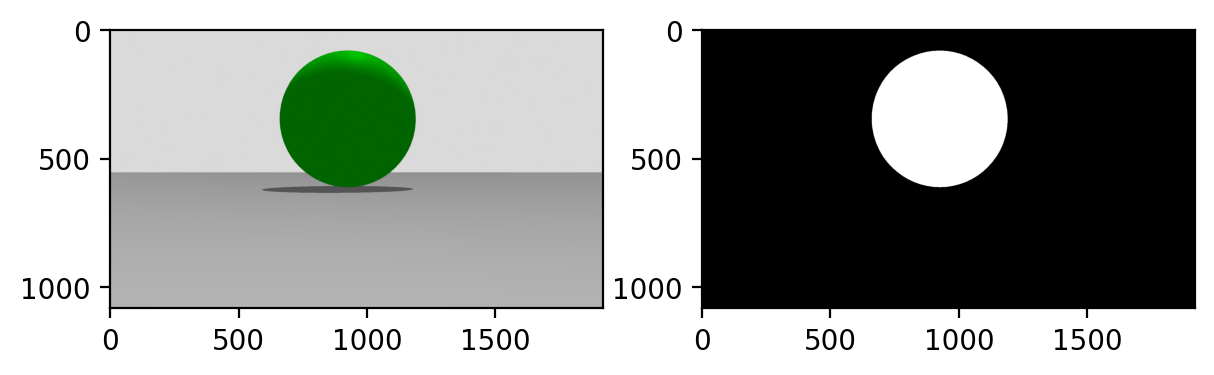

In [16]:
plt.figure(figsize=(7,7), dpi=200)
plt.subplot(121)
plt.imshow(img_rgb)
plt.subplot(122)
plt.imshow(green_mask, cmap='gray')

In [17]:
green_mask_result=cv2.bitwise_and(img_rgb, img_rgb, mask=green_mask)

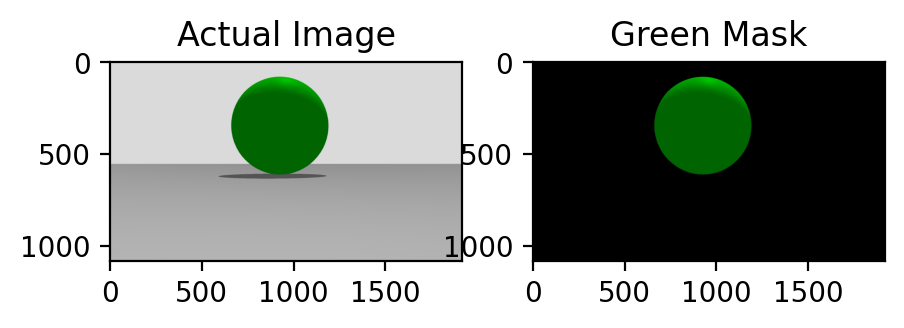

In [19]:
plt.figure(figsize=(5,5), dpi=200)
plt.subplot(121)
plt.title('Actual Image')
plt.imshow(img_rgb)
plt.subplot(122)
plt.title('Green Mask')
plt.imshow(green_mask_result)